In [1]:
%pip install tensorboard pandas


Note: you may need to restart the kernel to use updated packages.


In [2]:

%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
from packaging import version

import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats
import tensorboard as tb


In [4]:
major_ver, minor_ver, _ = version.parse(tb.__version__).release
assert major_ver >= 2 and minor_ver >= 3, \
    "This notebook requires TensorBoard 2.3 or later."
print("TensorBoard version: ", tb.__version__)


TensorBoard version:  2.13.0


In [6]:
from tensorboard.backend.event_processing import event_accumulator

# Het pad naar de map van je specifieke run/experiment
log_dir = "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/P/D/P_D_K/default/eval/eval_all_default/default/tensorboard_val" 

ea = event_accumulator.EventAccumulator(log_dir)
ea.Reload()

# Bekijk welke statistieken (tags) in dit 'experiment' zitten
print(ea.Tags())


{'images': [], 'audio': [], 'histograms': [], 'scalars': ['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'Car_aos/easy_R40', 'Car_aos/moderate_R40', 'Car_aos/hard_R40', 'Car_3d/easy_R40', 'Car_3d/moderate_R40', 'Car_3d/hard_R40', 'Car_bev/easy_R40', 'Car_bev/moderate_R40', 'Car_bev/hard_R40', 'Car_image/easy_R40', 'Car_image/moderate_R40', 'Car_image/hard_R40', 'Pedestrian_aos/easy_R40', 'Pedestrian_aos/moderate_R40', 'Pedestrian_aos/hard_R40', 'Pedestrian_3d/easy_R40', 'Pedestrian_3d/moderate_R40', 'Pedestrian_3d/hard_R40', 'Pedestrian_bev/easy_R40', 'Pedestrian_bev/moderate_R40', 'Pedestrian_bev/hard_R40', 'Pedestrian_image/easy_R40', 'Pedestrian_image/moderate_R40', 'Pedestrian_image/hard_R40', 'Cyclist_aos/easy_R40', 'Cyclist_aos/moderate_R40', 'Cyclist_aos/hard_R40', 'Cyclist_3d/easy_R40', 'Cyclist_3d/moderate_R40', 'Cyclist_3d/hard_R40', 'Cyclist_bev/easy_R40', 'Cyclist_bev/moderate_R40', 'Cyclist_bev/hard_R40', 'Cyc

In [17]:
if ea.Scalars('Car_3d/easy_R40'):
        print("yes")
        data = [(s.step, s.value) for s in ea.Scalars()]
        df = pd.DataFrame(data, columns=['epoch', 'performance'])
        print(pd.DataFrame(data, columns=['epoch', 'performance']))



yes


TypeError: Scalars() missing 1 required positional argument: 'tag'

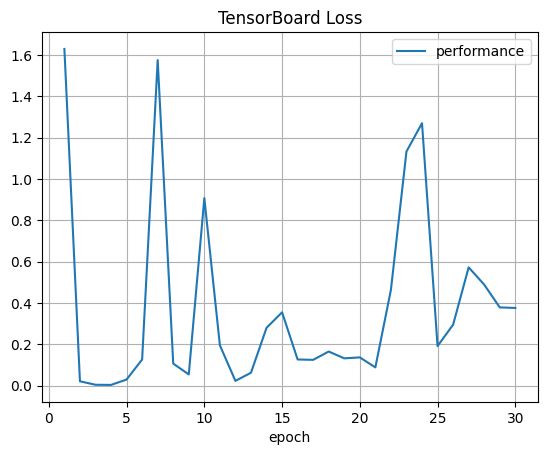

In [13]:
# Snel en direct plotten vanuit het DataFrame
df.plot(x='epoch', y='performance', kind='line', grid=True, title='TensorBoard Loss')
plt.show()


In [ ]:
def print_tb(log_dir)
    ea = event_accumulator.EventAccumulator(log_dir)
    ea.Reload()
    if  ea.Scalars('train/loss'):
        data = [(s.step, s.value) for s in ea.Scalars('train/loss')]
        df = pd.DataFrame(data, columns=['Step', 'Loss'])
        df.plot(x='Step', y='Loss', kind='line', grid=True, title='TensorBoard Loss')
        plt.show()
    